In [28]:
import torch
import torch.nn as nn
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt
import tonic

# Cria o dataset diretamente para que a célula seja autocontida
test_ds_3d = tonic.datasets.NMNIST("./nmnist", train=False)

# Escolhe uma amostra do NMNIST e faz um scatter 3D
sample_idx = 0
events, label = test_ds_3d[sample_idx]
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

GPU: None


In [29]:
import numpy as np

def export_tensor_to_txt(tensor, filename):
    """
    Exporta um tensor 5D para um arquivo de texto no formato de eventos.
    
    Args:
        tensor (np.ndarray): Tensor de entrada com shape (time_steps, batch_size, channels, height, width).
        filename (str): Caminho do arquivo de saída.
        
    Formato das colunas no arquivo TXT:
        type amplitude timestamp time_step batch channel height width
        
    Tipos de evento:
        0: Spike convencional
        1: Fim de passo temporal (TYPE_END_STEP)
        2: Fim de amostra/batch (TYPE_END_BATCH)
    """
    # Garante que é um array numpy (caso seja um tensor PyTorch)
    if hasattr(tensor, 'cpu'):
        tensor = tensor.cpu().numpy()
    elif not isinstance(tensor, np.ndarray):
        tensor = np.array(tensor)

    num_time_steps, batch_size, num_channels, height, width = tensor.shape
    
    with open(filename, 'w') as f:
        # Itera sobre cada amostra do batch
        for b in range(batch_size):
            # Itera sobre cada passo temporal
            for t in range(num_time_steps):
                # Otimização: Pega os índices onde existem spikes (valor != 0)
                # slice_data shape: (channels, height, width)
                slice_data = tensor[t, b]
                
                # Encontra coordenadas (c, h, w) dos spikes
                # Retorna tupla de arrays de indices (um array para cada dimensão)
                c_indices, h_indices, w_indices = np.nonzero(slice_data)
                
                # Itera sobre os spikes encontrados neste passo de tempo
                for i in range(len(c_indices)):
                    c = c_indices[i]
                    h = h_indices[i]
                    w = w_indices[i]
                    amplitude = slice_data[c, h, w]
                    
                    # Escreve pacote TYPE_SPIKE (0) apenas se amplitude != 0
                    if amplitude != 0:
                        # timestamp aqui é assumido igual ao time_step
                        f.write(f"0 {amplitude} {t} {t} {b} {c} {h} {w}\n")
                
                # Ao final de todos os spikes do passo t, escreve TYPE_END_STEP (1)
                # MODIFICADO: Não escreve TYPE_END_STEP se for o último passo (escreverá TYPE_END_BATCH depois)
                if t < num_time_steps - 1:
                    f.write(f"1 0 {t} {t} {b} 0 0 0\n")
            
            # Ao final de todos os passos temporais da amostra b, escreve TYPE_END_BATCH (2)
            last_t = num_time_steps - 1
            f.write(f"2 0 {last_t} {last_t} {b} 0 0 0\n")

    print(f"Arquivo gerado com sucesso: {filename}")

#export_tensor_to_txt(inp_data, "input_events.txt")

## Salva todo o dataset em arquivo txt

converte o dataset para o formato de evento e salva em um arquivo txt

In [30]:
import os
import tonic
import torch

bs = 128
steps = 300
collate = tonic.collation.PadTensors(batch_first=False)
to_frame = tonic.transforms.ToFrame(
    #sensor_size=tonic.datasets.NMNIST.sensor_size, time_window=1e3
    sensor_size=tonic.datasets.NMNIST.sensor_size, n_time_bins=steps
)
test_ds = tonic.datasets.NMNIST("./nmnist", transform=to_frame, train=False)

g = torch.Generator()
g.manual_seed(42)

test_dl = torch.utils.data.DataLoader(
    test_ds, shuffle=True, batch_size=bs, collate_fn=collate, generator=g
)

## Figura para artigo

In [31]:
def squeeze_channels(events):
    """
    Remove a dimensão de channel combinando os dois canais.
    Canal 0 mantém valores positivos, canal 1 é multiplicado por -1.
    
    Args:
        events (np.ndarray): Array com shape (time_step, channel, height, width)
        
    Returns:
        np.ndarray: Array com shape (time_step, height, width)
    """
    if hasattr(events, 'numpy'):  # Se for tensor PyTorch
        events = events.numpy()
    elif not isinstance(events, np.ndarray):
        events = np.array(events)
    
    # events shape: (time_step, channel, height, width)
    # Cria array de saída: (time_step, height, width)
    result = np.zeros((events.shape[0], events.shape[2], events.shape[3]))
    
    # Canal 0: valores positivos
    result += events[:, 0, :, :]
    
    # Canal 1: multiplicado por -1
    if events.shape[1] > 1:
        result -= events[:, 1, :, :]
    
    return result

In [32]:
# import math
# import matplotlib.pyplot as plt
# import numpy as np

# # Configurar a fonte para Times New Roman e aumentar o tamanho base
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# # Coletar uma amostra dos labels desejados: 0, 1 e 2
# desired_labels = [0, 1, 2]
# digit_samples = {}

# # Iterar pelo dataloader até achar uma amostra de cada label desejado
# for events, targets in test_dl:
#     # events shape com batch_first=False: (TimeSteps, Batch, Channels, Height, Width)
#     for b in range(events.shape[1]):
#         lbl = targets[b].item()
#         if lbl in desired_labels and lbl not in digit_samples:
#             # Aplica squeeze dos canais e salva
#             sample_data = squeeze_channels(events[:, b])  # (TimeSteps, Height, Width)
#             digit_samples[lbl] = sample_data
#         if len(digit_samples) == len(desired_labels):
#             break
#     if len(digit_samples) == len(desired_labels):
#         break

# selected_labels = desired_labels
# T = digit_samples[selected_labels[0]].shape[0]
# num_samples = len(selected_labels)

# # Grid com 3 linhas: uma para cada label, e colunas = timesteps
# fig, axes = plt.subplots(num_samples, T, figsize=(T * 2.5, num_samples * 2.5))

# # Garantir que axes seja 2D mesmo com T=1 ou num_samples=1
# if num_samples == 1:
#     axes = np.expand_dims(axes, axis=0)
# if T == 1:
#     axes = np.expand_dims(axes, axis=1)

# for idx, c in enumerate(selected_labels):  # Linhas = Labels 0, 1 e 2
#     sample = digit_samples[c]
#     # sample shape após squeeze: (TimeSteps, Height, Width)
#     H, W = sample.shape[1], sample.shape[2]
    
#     for r in range(T):  # Colunas = TimeSteps
#         # Após squeeze, temos um único canal com valores positivos e negativos
#         frame = sample[r]  # shape: (Height, Width)
        
#         # Cria imagem RGB onde:
#         # - Valores positivos aparecem em vermelho
#         # - Valores negativos (em azul)
#         img_rgb = np.zeros((H, W, 3))
        
#         # Normaliza para [0, 1]
#         frame_max = np.max(np.abs(frame))
#         if frame_max > 0:
#             frame_norm = frame / frame_max
#         else:
#             frame_norm = frame
        
#         # Canal 0 (vermelho): valores positivos
#         img_rgb[:, :, 0] = np.clip(frame_norm, 0, 1)
        
#         # Canal 2 (azul): valores negativos (inverte o sinal)
#         img_rgb[:, :, 2] = np.clip(-frame_norm, 0, 1)
        
#         ax = axes[idx, r]
        
#         ax.imshow(img_rgb)
#         ax.axis('off')
        
#         # Colocar o número do timestep (t) na primeira linha de cada coluna
#         if idx == 0:
#             ax.set_title(f"t={r}", fontsize=24)
            
#         # Colocar o rótulo (Label) na primeira coluna de cada linha
#         if r == 0:
#             ax.text(-0.1, 0.5, f"Label {c}", transform=ax.transAxes, 
#                     fontsize=24, va='center', ha='right')

# plt.tight_layout()
# plt.savefig("amostras_nmnist.pdf", format='pdf', bbox_inches='tight')
# plt.show()

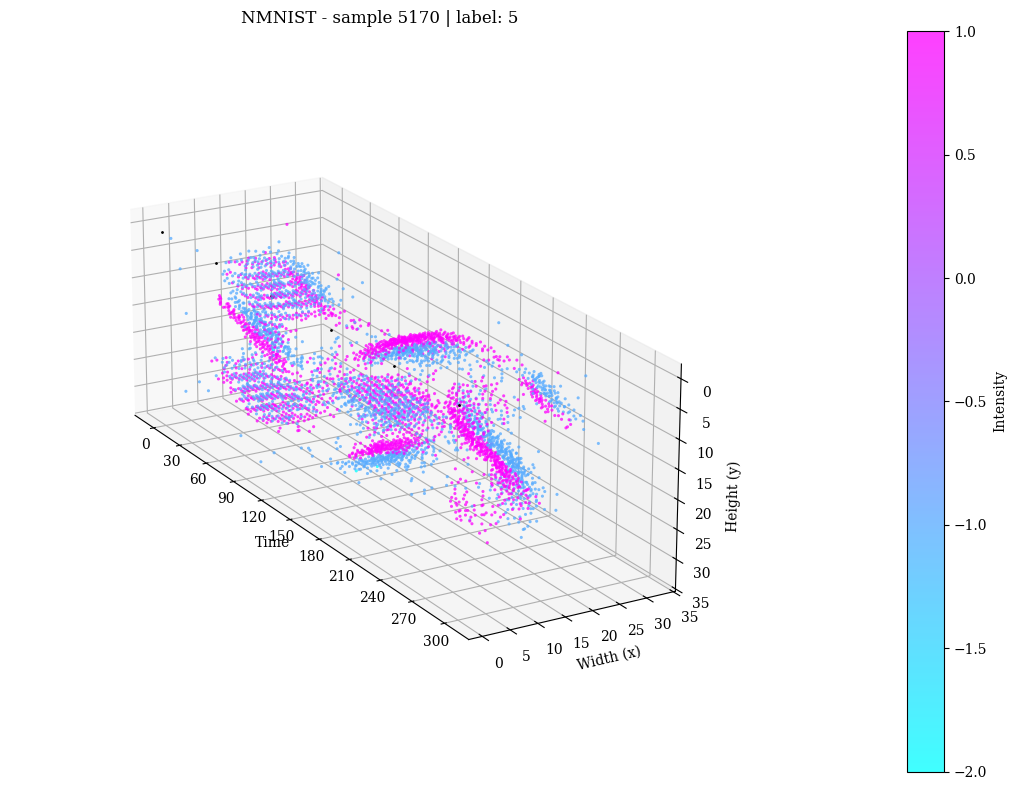

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Escolhe uma amostra do NMNIST e faz um scatter 3D
sample_idx = 5170
events, label = test_ds[sample_idx]

# Aplica squeeze dos canais: canal 0 positivo, canal 1 multiplicado por -1
events_squeezed = squeeze_channels(events)
# events_squeezed shape: (time_steps, height, width)

# Converte para lista de pontos (x, y, t, intensity)
points = []
for t in range(events_squeezed.shape[0]):
    frame = events_squeezed[t]  # shape: (height, width)
    # Encontra pontos com intensidade não-zero
    h_indices, w_indices = np.nonzero(frame)
    
    for i in range(len(h_indices)):
        h = h_indices[i]
        w = w_indices[i]
        intensity = frame[h, w]
        points.append([w, h, t, intensity])

if len(points) > 0:
    points = np.array(points)
    x = points[:, 0]
    y = points[:, 1]
    t = points[:, 2]
    p = points[:, 3]
else:
    x = np.array([])
    y = np.array([])
    t = np.array([])
    p = np.array([])

# Reduz a quantidade de pontos caso a amostra tenha muitos eventos
max_points = 8000
if len(x) > max_points:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x), size=max_points, replace=False)
    x = x[idx]
    y = y[idx]
    t = t[idx]
    p = p[idx]

# Converte o tempo para milissegundos para facilitar a leitura
if len(t) > 0 and np.nanmax(t) > 1000:
    t_plot = t / 1000.0
    time_label = "Time (ms)"
else:
    t_plot = t
    time_label = "Time"

if len(x) > 0:
    fig = plt.figure(figsize=(16, 8))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        t_plot,      # Tempo no eixo X
        x,           # Largura no eixo Y
        y,           # Altura no eixo Z
        c=p,         # Colorir pela intensidade/polaridade
        cmap="cool",
        s=5,
        alpha=0.75,
        linewidths=0,
    )

    # Desenha um ponto preto fixo em (0, 0, 4)
    ax.scatter([0], [0], [0], c="black", s=1, marker="o", depthshade=False)
    ax.scatter([60], [0], [0], c="black", s=1, marker="o", depthshade=False)
    ax.scatter([120], [0], [0], c="black", s=5, marker="o", depthshade=False)
    ax.scatter([180], [0], [0], c="black", s=1, marker="o", depthshade=False)
    ax.scatter([240], [0], [0], c="black", s=1, marker="o", depthshade=False)
    ax.scatter([300], [0], [0], c="black", s=1, marker="o", depthshade=False)

    # Ajusta a proporção dos eixos para alongar o eixo X visualmente
    ax.set_box_aspect([3, 1, 1])  # Proporção X:Y:Z = 3:1:1

    # Ticks do eixo X a cada 60 unidades
    ax.xaxis.set_major_locator(MultipleLocator(30))

    ax.set_xlabel(time_label)
    ax.set_ylabel("Width (x)")
    ax.set_zlabel("Height (y)")
    ax.invert_zaxis()
    # ax.invert_yaxis()
    ax.set_title(f"NMNIST - sample {sample_idx} | label: {label}")
    ax.view_init(elev=20, azim=-30)
    # ax.view_init(elev=0, azim=0)

    cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label("Intensity")

    plt.tight_layout()
    plt.savefig(f"nmnist_sample_{sample_idx}_3d.pdf", format="pdf", bbox_inches="tight")
    plt.show()
else:
    print(f"No events found in sample {sample_idx}")

In [12]:


# # Configurações de Saída
# output_dir = "n-mnist_dataset_events_txt"
# os.makedirs(output_dir, exist_ok=True)

# events_file_path = os.path.join(output_dir, "input_events.txt")
# targets_file_path = os.path.join(output_dir, "input_targets.txt")

# # Constantes do formato
# TYPE_SPIKE = 0
# TYPE_END_STEP = 1   # Fim de um passo de tempo (opcional, dependendo do seu TB)
# TYPE_END_SAMPLE = 2 # Fim de uma amostra (reset da rede)

# print(f"Salvando dataset em:\nEvents: {events_file_path}\nTargets: {targets_file_path}")

# # Abrir arquivos para escrita
# with open(events_file_path, "w") as f_ev, open(targets_file_path, "w") as f_tg:
    
#     # Escreve cabeçalho opcional (comentado para facilitar parser simples em C)
#     # f_ev.write("type amplitude timestamp time_step batch_idx channel_idx height_idx width_idx\n")
    
#     global_batch_idx = 0 # Contador global de amostras processadas

#     # Itera sobre o DataLoader (todo o dataset)
#     for batch_data, batch_targets in tqdm.tqdm(test_dl, desc="Processando Batches"):
        
#         # batch_data shape: [Time, Batch, Channel, Height, Width]
#         # Converter para CPU/Numpy se estiver em Tensor
#         if hasattr(batch_data, "cpu"):
#             batch_data = batch_data.detach().cpu().numpy()
#         if hasattr(batch_targets, "cpu"):
#             batch_targets = batch_targets.detach().cpu().numpy()

#         num_steps = batch_data.shape[0]
#         curr_batch_size = batch_data.shape[1]

#         # 1. Salvar Targets (Rótulos)
#         for t in batch_targets:
#             f_tg.write(f"{t}\n")

#         # 2. Salvar Eventos
#         # Iteramos amostra por amostra dentro do batch para manter a ordem sequencial global
#         for b in range(curr_batch_size):
            
#             # Para cada passo de tempo
#             for t in range(num_steps):
                
#                 # Extrai apenas os índices onde há spike (valor != 0)
#                 # O dado é esparso, então nonzero() é muito mais eficiente que varrer tudo
#                 # input slice: [Channel, Height, Width]
#                 frame = batch_data[t, b, :, :, :]
                
#                 # Indices: (canal, y, x)
#                 indices = frame.nonzero() 
                
#                 # Se houver spikes neste time step
#                 if len(indices[0]) > 0:
#                     c_idxs, h_idxs, w_idxs = indices
                    
#                     for i in range(len(c_idxs)):
#                         c = c_idxs[i]
#                         h = h_idxs[i]
#                         w = w_idxs[i]
#                         amp = frame[c, h, w]
                        
#                         # Formato: type amp timestamp time_step batch_idx channel height width
#                         # timestamp simulado = time_step * 1000 (exemplo)
#                         # timestamp = t * 1000
#                         timestamp = t 
                        
#                         line = (f"{TYPE_SPIKE} {int(amp)} {timestamp} {t} "
#                                 f"{global_batch_idx} {c} {h} {w}\n")
#                         f_ev.write(line)

#                # (Opcional) Marcador de Fim de Time Step para sincronia fina
#                 f_ev.write(f"{TYPE_END_STEP} 0 0 {t} {global_batch_idx} 0 0 0\n")

#             # Marcador de Fim de Amostra (Fundamental para resetar a rede no HLS)
#             # Timestamp e Time_step zerados ou finais, batch_idx atual
#             f_ev.write(f"{TYPE_END_SAMPLE} 0 0 {num_steps} {global_batch_idx} 0 0 0\n")
            
#             # Incrementa o contador global de batch para que o HLS saiba que mudou de imagem
#             global_batch_idx += 1

# print(f"Concluído! Total de amostras processadas: {global_batch_idx}")

In [13]:
import numpy as np
import torch
import os

def export_dataloader_to_txt(dataloader, filename_data, filename_targets, max_samples=None):
    """
    Exporta dados de um DataLoader para um arquivo de texto no formato de eventos e os targets para outro arquivo.
    
    Args:
        dataloader: DataLoader do PyTorch contendo os dados.
        filename_data (str): Caminho do arquivo de saída para os dados (eventos).
        filename_targets (str): Caminho do arquivo de saída para os targets (labels).
        max_samples (int, optional): Número máximo de amostras a exportar. Se None, exporta todas.
        
    Formato das colunas no arquivo TXT de dados:
        type amplitude timestamp time_step batch channel height width
        
    Tipos de evento:
        0: Spike convencional
        1: Fim de passo temporal (TYPE_END_STEP)
        2: Fim de amostra/batch (TYPE_END_BATCH)
    """
    sample_count = 0
    
    with open(filename_data, 'w') as f_data, open(filename_targets, 'w') as f_targets:
        for batch_idx, (data, labels) in enumerate(dataloader):
            # Converte para numpy se necessário
            if hasattr(data, 'cpu'):
                data = data.cpu().numpy()
            elif not isinstance(data, np.ndarray):
                data = np.array(data)
                
            if hasattr(labels, 'cpu'):
                labels = labels.cpu().numpy()
            elif not isinstance(labels, np.ndarray):
                labels = np.array(labels)
                
            # Assume shape: (batch_size, time_steps, channels, height, width)
            # Se o shape for diferente, ajuste conforme necessário
            if data.ndim == 4:  # Se for (batch, channels, height, width)
                data = np.expand_dims(data, 1)  # Adiciona dimensão temporal
            
            batch_size = data.shape[1]
            num_time_steps = data.shape[0]
            
            # Determina o tamanho real do batch considerando max_samples
            actual_batch_size = batch_size
            if max_samples is not None and sample_count + batch_size > max_samples:
                actual_batch_size = max_samples - sample_count
                
            if actual_batch_size <= 0:
                break

            # Itera sobre cada amostra do batch
            for b in range(actual_batch_size):
                batch_global = sample_count + b
                
                # Escreve o target para esta amostra
                if labels.ndim > 0 and len(labels) > b:
                    label = labels[b]
                elif labels.ndim == 0:
                    label = labels
                else:
                    label = labels[0] # Fallback
                f_targets.write(f"{label}\n")
                
                # Itera sobre cada passo temporal
                for t in range(num_time_steps):
                    # slice_data shape: (channels, height, width)
                    slice_data = data[t, b]
                    
                    # Encontra coordenadas (c, h, w) dos spikes
                    c_indices, h_indices, w_indices = np.nonzero(slice_data)
                    
                    # Itera sobre os spikes encontrados neste passo de tempo
                    for i in range(len(c_indices)):
                        c = c_indices[i]
                        h = h_indices[i]
                        w = w_indices[i]
                        amplitude = slice_data[c, h, w]
                        
                        # Escreve pacote TYPE_SPIKE (0) apenas se amplitude != 0
                        if amplitude != 0:
                            f_data.write(f"0 {amplitude} {t} {t} {batch_global} {c} {h} {w}\n")
                    
                    # Ao final de todos os spikes do passo t, escreve TYPE_END_STEP (1) ou TYPE_END_BATCH (2)
                    
                    f_data.write(f"1 0 {t} {t} {batch_global} 0 0 0\n")
                    
                f_data.write(f"2 0 {t} {t} {batch_global} 0 0 0\n")
            
            prev_count = sample_count
            sample_count += actual_batch_size
            
            if (prev_count // 100) < (sample_count // 100):
                print(f"Processadas {sample_count} amostras...")
                
            if max_samples is not None and sample_count >= max_samples:
                break
    
    print(f"Arquivos gerados com sucesso: {filename_data} e {filename_targets}")
    print(f"Total de amostras exportadas: {sample_count}")


# Configuração dos caminhos
output_dir = f"n-mnist_test_{steps}_steps_txt"
os.makedirs(output_dir, exist_ok=True)

events_file = os.path.join(output_dir, "nmnist_test_events_full.txt")
targets_file = os.path.join(output_dir, "nmnist_test_targets_full.txt")

# Exemplo de uso com o dataloader existente
# Certifique-se de que o dataloader está definido antes de executar
# export_dataloader_to_txt(dataloader, os.path.join(output_dir, "nmnist_test_events.txt"), os.path.join(output_dir, "nmnist_test_targets.txt"), max_samples=1000)

# Se quiser exportar todas as amostras do test_dl:
export_dataloader_to_txt(test_dl, events_file, targets_file)

Processadas 128 amostras...
Processadas 256 amostras...
Processadas 384 amostras...
Processadas 512 amostras...
Processadas 640 amostras...
Processadas 768 amostras...
Processadas 896 amostras...
Processadas 1024 amostras...
Processadas 1152 amostras...
Processadas 1280 amostras...
Processadas 1408 amostras...
Processadas 1536 amostras...
Processadas 1664 amostras...
Processadas 1792 amostras...
Processadas 1920 amostras...
Processadas 2048 amostras...
Processadas 2176 amostras...
Processadas 2304 amostras...
Processadas 2432 amostras...
Processadas 2560 amostras...
Processadas 2688 amostras...
Processadas 2816 amostras...
Processadas 2944 amostras...
Processadas 3072 amostras...
Processadas 3200 amostras...
Processadas 3328 amostras...
Processadas 3456 amostras...
Processadas 3584 amostras...
Processadas 3712 amostras...
Processadas 3840 amostras...
Processadas 3968 amostras...
Processadas 4096 amostras...
Processadas 4224 amostras...
Processadas 4352 amostras...
Processadas 4480 amos

In [14]:
# for batch_idx, (data, labels) in enumerate(test_dl):
#     print(f"Batch {batch_idx}: data shape = {data.shape}, labels shape = {labels.shape}")